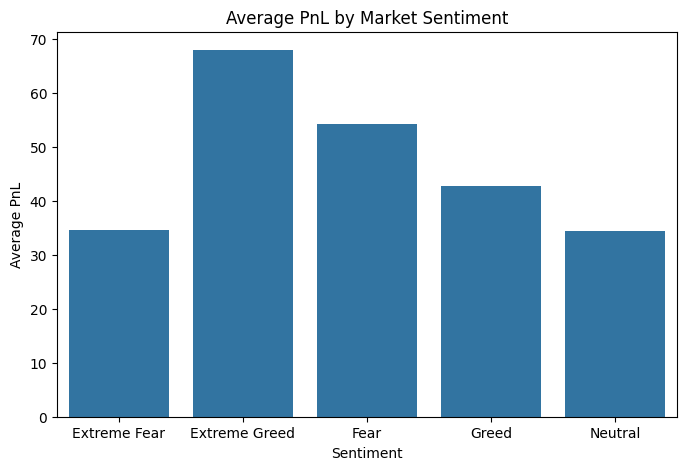

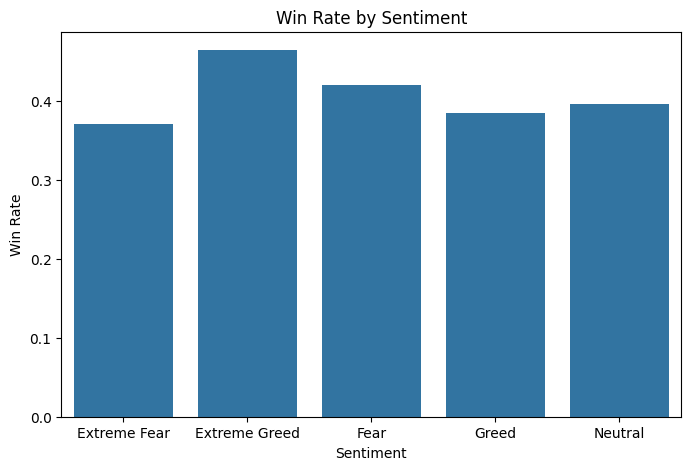


✅ Average PnL:
 classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: closed pnl, dtype: float64

✅ Win Rate:
 classification
Extreme Fear     0.370607
Extreme Greed    0.464943
Fear             0.420768
Greed            0.384828
Neutral          0.396991
dtype: float64

🎯 Done! Your analysis is complete.


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# STEP 1: Load datasets
# -------------------------------
trader = pd.read_csv("/content/sample_data/historical_data.csv")
sentiment = pd.read_csv("/content/sample_data/fear_greed_index.csv")

# -------------------------------
# STEP 2: Clean column names
# -------------------------------
trader.columns = trader.columns.str.strip().str.lower()
sentiment.columns = sentiment.columns.str.strip().str.lower()

# -------------------------------
# STEP 3: Convert date columns
# -------------------------------
# Fix date format (DD-MM-YYYY)
trader['date'] = pd.to_datetime(
    trader['timestamp ist'],
    dayfirst=True,
    errors='coerce'
).dt.date

sentiment['date'] = pd.to_datetime(
    sentiment['date'],
    errors='coerce'
).dt.date

# -------------------------------
# STEP 4: Merge datasets
# -------------------------------
df = pd.merge(trader, sentiment, on='date', how='left')

# -------------------------------
# STEP 5: Feature Engineering
# -------------------------------
df['pnl_category'] = df['closed pnl'].apply(
    lambda x: 'Profit' if x > 0 else 'Loss'
)

# -------------------------------
# STEP 6: Analysis
# -------------------------------

# Avg PnL by Sentiment
pnl_sentiment = df.groupby('classification')['closed pnl'].mean()

# Win Rate
win_rate = (
    df[df['closed pnl'] > 0]
    .groupby('classification')
    .size()
    / df.groupby('classification').size()
)

# Leverage (only if exists)
if 'leverage' in df.columns:
    leverage = df.groupby('classification')['leverage'].mean()

# -------------------------------
# STEP 7: Visualization
# -------------------------------

plt.figure(figsize=(8,5))
sns.barplot(x=pnl_sentiment.index, y=pnl_sentiment.values)
plt.title("Average PnL by Market Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average PnL")
plt.show()

plt.figure(figsize=(8,5))
sns.barplot(x=win_rate.index, y=win_rate.values)
plt.title("Win Rate by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Win Rate")
plt.show()

# Plot leverage if available
if 'leverage' in df.columns:
    plt.figure(figsize=(8,5))
    sns.barplot(x=leverage.index, y=leverage.values)
    plt.title("Average Leverage by Sentiment")
    plt.xlabel("Sentiment")
    plt.ylabel("Leverage")
    plt.show()

# -------------------------------
# STEP 8: Save output
# -------------------------------
df.to_csv("final_analysis.csv", index=False)

# -------------------------------
# STEP 9: Print insights (basic)
# -------------------------------
print("\n✅ Average PnL:\n", pnl_sentiment)
print("\n✅ Win Rate:\n", win_rate)

print("\n🎯 Done! Your analysis is complete.")